© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# **Series and Masks**

**Deep Network Development W03/A**

**Topic:** elementwise arithmetic, collapse operations, slicing, boolean masks and selection by index, applied to a year of hourly readings.

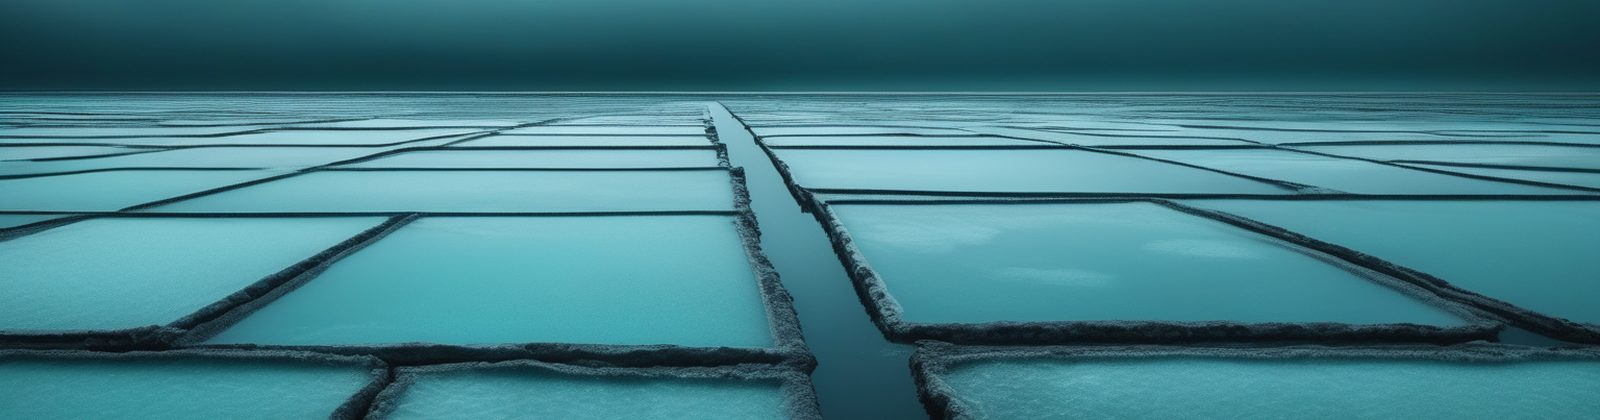

## **What this is**

Two measurements taken once an hour for a year, 8760 readings each. Three parts, between them covering the operations from the session: elementwise arithmetic, reductions, slicing, boolean masks and selection by index.

| Part | Asks for | Points |
|---|---|---:|
| a | The total water level above the chart datum, in 30 stretches of the year | 30 |
| b | How many hours satisfy 30 pairs of conditions | 35 |
| c | When the water level first passed a mark, and the total at 30 named hours | 35 |

Each part wants a CSV with columns `id,target`, one integer per row, scored exact-match: `points * (correct rows / total rows)`.

Every part works on a single axis. Nothing in this exercise has a second one.

## **What exactly is being asked**

`level.npy` holds 8760 harbour water levels in whole centimetres, one an hour for a year, in time order. `wind.npy` holds the wind speed in whole km/h for the very same hours, so `level[i]` and `wind[i]` describe the same hour. `queries.json` holds what each part asks about. Indices are **0-based** and every answer is an integer.

The **chart datum** is `200` centimetres. It is the reference mark the harbour measures against, and part a is the only part that uses it.

**Part a, from `windows`.** Each window is `[i0, i1]`, a stretch of consecutive hours. The bounds are **half-open**, exactly as Python slicing means them: hour `i0` is inside, hour `i1` is not. Take the **water level** at every hour in that stretch, that is the values in `level`, subtract the chart datum of `200` from each one, and report the **total** of what is left. The result can be negative. Part a does not use `wind`.

**Part b, two row groups.** A condition is counted over the whole year, not over any window.

Rows `id = 0..14`, from `and_conditions`. Each is `[level_min, wind_max]`. Report how many hours had a level of **at least** `level_min` **and** a wind speed of **at most** `wind_max`. Both bounds are inclusive.

Rows `id = 15..29`, from `or_conditions`. Each is `[level_min, wind_min]`. Report how many hours had a level of **at least** `level_min` **or** a wind speed of **at least** `wind_min`, or both. Both bounds are inclusive again. Read the two groups carefully: they ask different questions and one is not the other with a word changed.

**Part c, two row groups.**

Rows `id = 0..14`, from `thresholds`. Each threshold is a water level in centimetres. For each one, report the **hour index** of the first hour of the year whose value in `level` is **strictly greater** than that threshold. Some of these thresholds are above anything the harbour reached all year. When `level` never passes the mark, report **`-1`**, which is the only answer here that is not an hour.

Rows `id = 15..29`, from `gathers`. Each is a list of 20 hour indices, not a range. Add up the values of `level` at exactly those 20 hours and report that total. Like the rest of part c, this group does not use `wind`.

## **Useful Links**

- [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- [Indexing on ndarrays](https://numpy.org/doc/stable/user/basics.indexing.html)
- [Array creation](https://numpy.org/doc/stable/user/basics.creation.html)
- [Routines reference](https://numpy.org/doc/stable/reference/routines.html)

## **Setup and data**

In [1]:
# ══════════════════════════════════════════════════════════
# Setup. DO NOT MODIFY.
# ══════════════════════════════════════════════════════════
import csv
import json
from pathlib import Path

import numpy as np

def write_submission(filename, rows):
    """Write [(id, target), ...] as a DOCK-ready CSV.

    Every part of every exercise this semester ends with a call like this one.
    """
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["id", "target"])
        for row_id, target in rows:
            writer.writerow([int(row_id), int(target)])
    print(f"wrote {filename}: {len(rows)} rows")

# Download level.npy, wind.npy and queries.json from the exercise page on DOCK and
# put them next to this notebook (in Colab: drag them into the file browser on the left).
def _find(name):
    here = Path(name)
    return here if here.exists() else Path("data") / name

level = np.load(_find("level.npy"))
wind = np.load(_find("wind.npy"))
queries = json.loads(_find("queries.json").read_text(encoding="utf-8"))

DATUM = 200

windows = queries["windows"]
and_conditions = queries["and_conditions"]
or_conditions = queries["or_conditions"]
thresholds = queries["thresholds"]
gathers = queries["gathers"]

print(f"level: {level.shape} {level.dtype}, {level.min()} to {level.max()} cm")
print(f"wind:  {wind.shape} {wind.dtype}, {wind.min()} to {wind.max()} km/h")
print(f"{len(windows)} windows, {len(and_conditions)} + {len(or_conditions)} conditions, "
      f"{len(thresholds)} thresholds, {len(gathers)} gathers")

level: (8760,) int64, 87 to 381 cm
wind:  (8760,) int64, 0 to 178 km/h
30 windows, 15 + 15 conditions, 15 thresholds, 15 gathers


## **A first look**

In [2]:
# ── A first look (display helper, no need to modify) ──
def summarise(name, arr):
    print(f"{name:6s} first five: {arr[:5]}")
    print(f"{name:6s} lowest {arr.min()}, highest {arr.max()}, {len(arr)} readings")

summarise("level", level)
summarise("wind", wind)
print(f"\nthe first window is {windows[0]}, covering {windows[0][1] - windows[0][0]} hours")

level  first five: [216 266 284 284 297]
level  lowest 87, highest 381, 8760 readings
wind   first five: [25 34 22 20 37]
wind   lowest 0, highest 178, 8760 readings

the first window is [1756, 2167], covering 411 hours


---
## **Part a: The total above the datum (30 points)**

Two operations apply to every `level` reading in the window, and the window then reduces to a single number. Watch the bounds: `i1` is not part of the window.

Submission: `part1_submission.csv`, one row per window, uploaded to part a.

In [43]:
#part1 = [(i, 0) for i in range(len(windows))]

# ── Your code starts here ──
l = []
for i in range(len(windows)):
    l.append(np.sum(level[windows[i][0]:windows[i][1]] - 200))
    

part1 = [(i, l[i]) for i in range(len(windows))]

write_submission("part1_submission.csv", part1)

len(l), len(part1), part1[:5]

wrote part1_submission.csv: 30 rows


(30,
 30,
 [(0, np.int64(13551)),
  (1, np.int64(12226)),
  (2, np.int64(-632)),
  (3, np.int64(6448)),
  (4, np.int64(-1481))])

---
## **Part b: Counting the hours (35 points)**

Two row groups, graded together but asking different things. The first wants hours that satisfy **both** conditions, the second wants hours that satisfy **either**.

Two warnings. Python's `and` and `or` want a single true-or-false answer and will refuse a whole year of them, so the elementwise forms are what this part needs. And those operators bind more tightly than the comparisons do, so each comparison needs its own brackets or the answer is not the one you meant.

Submission: `part2_submission.csv`, 30 rows, uploaded to part b.

In [ ]:
level >= and_conditions[i][0]

In [70]:
part2 = []

# ── Your code starts here ──

print(and_conditions[:5])

for i in range(len(and_conditions) + len(or_conditions)):
    if i < len(and_conditions): # rows 0..14   level at least level_min AND no more than wind_max for the wind speed
        part2.append([i, np.count_nonzero((level >= and_conditions[i][0]) & (wind <= and_conditions[i][1]))])
        
    else: # rows 15..29  level at least level_min OR wind more than wind_min OR ALSO BOTH
        part2.append([i, np.count_nonzero((level >= or_conditions[i - len(and_conditions)][0]) | (wind >= or_conditions[i - len(and_conditions)][1]))])
    
write_submission("part2_submission.csv", part2)
part2[:5]

[[186, 20], [216, 26], [257, 33], [270, 10], [182, 17]]
wrote part2_submission.csv: 30 rows


[[0, np.int64(2627)],
 [1, np.int64(2679)],
 [2, np.int64(1928)],
 [3, np.int64(310)],
 [4, np.int64(2222)]]

---
## **Part c: First crossing, and named hours (35 points)**

Two row groups, graded together.

The first group asks when the level **first** went above a mark. Some marks were never reached, and those rows want `-1`. Check what your method returns when no hour qualifies before you trust it: an hour index of `0` is the correct answer for some of these thresholds and wrong for others, so the two cases have to be told apart.

The second group hands you a list of hours and wants the total water level across them. The hours are not consecutive and are not a range, so a slice will not reach them.

Submission: `part3_submission.csv`, 30 rows, uploaded to part c.

In [109]:
part3 = [[i, 0] for i in range(len(thresholds) + len(gathers))]

print(level)
print(gathers[0])

for i in range(len(thresholds) + len(gathers)):
    if i < len(thresholds): # rows 0..14   hour of the first `level` strictly above the threshold, or -1 if never
        tmp_arr = np.where(level > thresholds[i])[0]
        
        if len(tmp_arr) >= 1:
            part3[i][1] = tmp_arr[0]
        else:
            part3[i][1] = -1
        
    else: # rows 15..29  total of the `level` values at exactly the listed hours
        part3[i][1] = np.sum(level[gathers[i - len(thresholds)]])


write_submission("part3_submission.csv", part3)

[216 266 284 ... 272 321 313]
[218, 417, 714, 972, 1116, 1856, 2308, 2481, 2768, 3107, 3612, 4768, 5120, 5131, 5975, 6127, 6951, 7163, 7950, 8614]
wrote part3_submission.csv: 30 rows


---
## **Before you leave**

Upload each CSV to its own part on DOCK.

